# WellClass: load, validate, and derive a well

This recipe is only about WellClass. It loads the typed Frigg example, keeps the raw input available, and derives well path, TVD intervals, borehole, cement bond, and annulus data.

## `src/WellClass/libs` architecture overview

The `WellClass` package is organized into focused subpackages, each covering one concern of the
well-modeling pipeline:

- **`models/`** — Pydantic input schema (`well_model.py`, `scalar_unit_model.py`) used to validate
  raw well JSON/YAML input (units, required fields) before it is consumed downstream.
- **`well_class/`** — The core dataclasses: `Well` (`well_class.py`, raw/validated input),
  `WellRaw` (`well_raw.py`), `WellProcessed` (`well_processed.py`, derived geometry/wellpath/plug
  data used throughout this notebook), and `well_validation.py` (consistency checks, e.g. hole
  continuity).
- **`well_computed/`** — Pure functions that derive geometric segments from the raw well
  (`borehole.py`, `annulus.py`, `casings_cement.py`, `cement_bond.py`, `plugs_diameter.py`,
  `plug_properties.py`, `barriers_names.py`, `well_path.py`). `WellProcessed` composes these to
  build `borehole`, `annulus`, `cement_bond`, `processed_plugs`, etc.
- **`well_pressure/`** — Pressure/PVT modeling (`pressure.py`, `pressure_table.py`,
  `pressure_scenario.py`, `barrier_pressure.py`, `co2_pressure.py`) used to build hydrostatic and
  CO2 pressure profiles for a reservoir scenario.
- **`pvt/`** — Low-level PVT lookups (`pvt.py`) for CO2/brine density, temperature, and
  hydrostatic pressure from tabulated constants — used directly in this notebook's pressure QC
  section.
- **`plotting/`** — Visualization helpers: `plot_sketch.py` (WellClass-only well sketch, used
  extensively below), `plot_pressure.py`/`plot_pt.py` (require a full `Pressure` reservoir
  scenario — GaP-dependent, not exercised here), `plot_grids.py` (combines a sketch with a GaP
  grid slice — not applicable to a WellClass-only notebook), and `plot_utils.py`.
- **`grid_utils/`** — GaP grid/LGR construction (`LGR_builder.py`, `grid_refine.py`,
  `grid_coarse.py`, etc.) that consumes a `WellProcessed` instance to build simulation grids;
  out of scope for this notebook, see `02_gap_grid.ipynb` / `03_wellclass_to_gap.ipynb`.
- **`utils/`** — Generic helpers (CSV/YAML parsing, fraction-to-float conversion, interval
  intersection) shared across the other subpackages.

This notebook focuses on the `well_class/`, `well_computed/`, `pvt/`, and `plotting/plot_sketch`
subpackages — i.e. everything needed to load, validate, and inspect a single well independent of
any GaP grid or reservoir pressure scenario.

```mermaid
flowchart TB
    subgraph core["well_class/"]
        Well["Well / WellRaw"]
        WellProcessed["WellProcessed"]
        validation["well_validation.py"]
    end

    subgraph computed["well_computed/"]
        borehole["borehole.py / annulus.py"]
        cement["casings_cement.py / cement_bond.py"]
        plugs["plugs_diameter.py / plug_properties.py"]
        wellpath["well_path.py"]
    end

    subgraph pressure["well_pressure/"]
        Pressure["Pressure\n(owns tables and scenarios)"]
        PressureTable["PressureTable(s)\nbackground curves per sensitivity"]
        PressureScenario["PressureScenario(s)\nbrine/fluid curves + metadata"]
        co2["co2_pressure.py\nlegacy pandas helpers"]
    end

    subgraph viz["plotting/"]
        plot_sketch["plot_sketch.py"]
        plot_pt["plot_pressure.py / plot_pt.py (needs Pressure scenario)"]
        plot_grids["plot_grids.py (needs GaP grid)"]
    end

    subgraph grid["grid_utils/ (GaP, out of scope here)"]
        LGR["LGR_builder.py / grid_refine.py"]
    end

    models["models/ WellModel schema"] --> Well
    Well --> validation
    Well --> WellProcessed
    borehole --> WellProcessed
    cement --> WellProcessed
    plugs --> WellProcessed
    wellpath --> WellProcessed
    pvt["pvt/pvt.py\nCO2 density tables"] --> PressureScenario

    WellProcessed --> plot_sketch
    WellProcessed --> LGR
    WellProcessed -->|header fields| Pressure
    Pressure -->|creates 1..n| PressureTable
    Pressure -->|creates 1..n| PressureScenario
    PressureScenario -.uses selected table.-> PressureTable
    PressureScenario --> plot_pt
    LGR --> plot_grids

    classDef inScope fill:#d4f7dc,stroke:#2e7d32;
    classDef outScope fill:#f0f0f0,stroke:#9e9e9e,stroke-dasharray: 4 3;
    class Well,WellProcessed,validation,borehole,cement,plugs,wellpath,plot_sketch,pvt,models,Pressure,PressureTable,PressureScenario inScope;
    class co2,plot_pt,plot_grids,LGR outScope;
```

*Green = exercised in this notebook; grey/dashed = GaP or reservoir-pressure-scenario dependent,
covered by `02_gap_grid.ipynb` / `03_wellclass_to_gap.ipynb` instead.*

In [1]:
from pathlib import Path
import pandas as pd
from src.WellClass.libs.well_class import Well, WellProcessed

root = Path.cwd()
if not (root / 'test_data').exists():
    root = root.parent
frigg_json = root / 'test_data/examples/frigg/frigg.json'

## Plot styling (optional)

`plot_sketch` and the other plotting helpers deliberately stay agnostic of global look-and-feel
(dpi, fonts) — they only draw onto whatever `Axes` they're given. Presentation styling like this
belongs at the notebook/report level, not inside the plotting functions, so different consumers
can apply their own style without touching WellClass code.

In [2]:
from matplotlib import font_manager, rcParams

rcParams['figure.dpi'] = 200
rcParams['font.family'] = 'Equinor'
rcParams['font.size'] = 9

font_path = root / 'notebooks/Equinor_regular'
for font_file in font_manager.findSystemFonts(fontpaths=str(font_path)):
    font_manager.fontManager.addfont(font_file)

## Raw and processed representations

In [3]:
raw_well = Well.from_json(frigg_json)
processed_well = WellProcessed.from_json(frigg_json)

print(raw_well.inventory)
print(processed_well.inventory)
print(processed_well.header)

{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'hole_casings': True, 'survey': True, 'plugs': True, 'stratigraphy': True}
{'unique_wellbore_identifier': 'NO 25/1-10', 'depth_reference_rkb': 27.0, 'depth_reference_rkb_unit': 'm', 'ground_elevation': 99.0, 'ground_elevation_unit': 'm', 'total_depth_rkb': 4739.0, 'total_depth_rkb_unit': 'm'}


## Derived WellClass data

In [4]:
hole_casings = pd.DataFrame(processed_well.hole_casings)
borehole = pd.DataFrame(processed_well.borehole)
annulus = pd.DataFrame(processed_well.annulus)
casing_cement = pd.DataFrame(processed_well.casing_cement)
cement_bond = pd.DataFrame(processed_well.cement_bond)

display(hole_casings[['name', 'type', 'top_rkb', 'bottom_rkb', 'diameter_in']])
display(borehole[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'diameter_m']])
display(annulus[['top_rkb', 'bottom_rkb', 'top_tvd_msl', 'bottom_tvd_msl', 'an_thickness_m']])
print('Input casing-cement intervals:', len(casing_cement))
print('Derived cement-bond regions:', len(cement_bond))

,name,type,top_rkb,bottom_rkb,diameter_in
0,Hole 36 in,hole,126.0,189.0,36.000
1,Hole 26 in,hole,189.0,923.0,26.000
2,Hole 17 1/2 in,hole,923.0,2839.0,17.500
3,Hole 12 1/4 in,hole,2839.0,4085.0,12.250
4,Hole 8 3/8 in,hole,4085.0,4470.0,8.375
5,Hole 5 7/8 in,hole,4470.0,4739.0,5.875
6,Casing 30 in,casing,126.0,188.0,30.000
7,Casing 20 in,casing,126.0,910.0,20.000
8,Casing 13 3/8 in,casing,693.0,2825.0,13.375
9,Casing 9 5/8 in,casing,785.0,4043.0,9.625


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,diameter_m
0,126.0,693.0,98.998273,665.981527,0.508000
1,693.0,785.0,665.981527,757.955759,0.339725
2,785.0,3936.0,757.955759,3906.982380,0.244475
3,3936.0,4470.0,3906.982380,4436.829077,0.177800
4,4470.0,4739.0,4436.829077,4704.694542,0.149225


,top_rkb,bottom_rkb,top_tvd_msl,bottom_tvd_msl,an_thickness_m
0,126.0,188.0,98.99827266276596,160.99659919577508,0.076200
1,126.0,188.0,98.99827266276596,160.99659919577508,0.127000
2,188.0,189.0,160.99659919577508,161.9965799228727,0.203200
3,189.0,910.0,161.9965799228727,882.9431765909171,0.076200
4,693.0,910.0,665.9815272015866,882.9431765909171,0.084138
5,785.0,2825.0,757.9557593964954,2797.287090121351,0.047625
6,910.0,923.0,882.9431765909171,895.9427446136193,0.160337
7,923.0,2825.0,895.9427446136193,2797.287090121351,0.052388
8,2825.0,2839.0,2797.287090121351,2811.286861302984,0.100013
9,2839.0,4043.0,2811.286861302984,4012.7886710250723,0.033337


Input casing-cement intervals: 5
Derived cement-bond regions: 11


## Well path and MD-to-TVD conversion

In [5]:
import numpy as np

# processed_well.wellpath is a wellpathpy position_log built from the survey
deviation = processed_well.wellpath.deviation()
print('survey stations:', len(deviation.md))

# processed_well.md2tvd(...) converts a measured depth (mRKB) to TVD MSL
sample_md = np.linspace(0, processed_well.header['total_depth_rkb'], 5)
for md in sample_md:
    print(f'MD {md:8.1f} mRKB -> TVD {float(processed_well.md2tvd(md)):8.1f} mMSL')

survey stations: 159
MD      0.0 mRKB -> TVD    -27.0 mMSL
MD   1184.8 mRKB -> TVD   1157.7 mMSL
MD   2369.5 mRKB -> TVD   2341.8 mMSL
MD   3554.2 mRKB -> TVD   3526.1 mMSL
MD   4739.0 mRKB -> TVD   4704.7 mMSL


## Stratigraphy and plugs

In [6]:
stratigraphy = pd.DataFrame(processed_well.stratigraphy)
plugs = pd.DataFrame(processed_well.plugs)
processed_plugs = pd.DataFrame(processed_well.processed_plugs)

display(stratigraphy[['name', 'top_rkb', 'bottom_rkb', 'tvd_msl_top', 'tvd_msl_bottom']])
display(plugs[['name', 'type', 'top_rkb', 'bottom_rkb']])
display(processed_plugs[['name', 'segment', 'top_rkb', 'bottom_rkb', 'diameter_m']])
print('Plug names:', processed_well.plug_names)

,name,top_rkb,bottom_rkb,tvd_msl_top,tvd_msl_bottom
0,NORDLAND SAND&CLAY,126.0,238.0,98.99827266276596,210.99547492829637
1,UTSIRA SANDS,238.0,738.0,210.99547492829637,710.9676918059426
2,HORDALAND 3 CLAY,738.0,900.0,710.9676918059426,872.9435762552223
3,SKADE SAND,900.0,916.0,872.9435762552223,888.9429663800049
4,HORDALAND 2 CLAY,916.0,1300.0,888.9429663800049,1272.896936291503
5,GRID SANDS?,1300.0,1350.0,1272.896936291503,1322.8758731102405
6,HORDALAND 1 GREEN CLAY,1350.0,1926.0,1322.8758731102405,1898.6573598386906
7,FRIGG SANDS,1926.0,2171.0,1898.6573598386906,2143.4652476707683
8,BALDER FM,2171.0,2291.0,2143.4652476707683,2263.3769874750556
9,SELE FM,2291.0,2423.0,2263.3769874750556,2395.326186657285


,name,type,top_rkb,bottom_rkb
0,cplug9,cement,148.0,230.0
1,cplug8,cement,230.0,370.0
2,cplug7,cement,604.0,721.0
3,cplug6,cement,721.0,835.0
4,bplug2,mechanical plug,3842.0,3842.5
5,cplug5,cement,3847.0,3981.0
6,bplug1,mechanical plug,4156.0,4156.5
7,cplug4,cement,4164.0,4532.0
8,cplug3,cement,4534.0,4735.0


,name,segment,top_rkb,bottom_rkb,diameter_m
0,cplug9,0,148.0,230.0,0.508000
1,cplug8,0,230.0,370.0,0.508000
2,cplug7,0,604.0,693.0,0.508000
3,cplug7,1,693.0,721.0,0.339725
4,cplug6,0,721.0,785.0,0.339725
5,cplug6,1,785.0,835.0,0.244475
6,bplug2,0,3842.0,3842.5,0.244475
7,cplug5,0,3847.0,3936.0,0.244475
8,cplug5,1,3936.0,3981.0,0.177800
9,bplug1,0,4156.0,4156.5,0.177800


Plug names: ['cplug9', 'cplug8', 'cplug7', 'cplug6', 'bplug2', 'cplug5', 'bplug1', 'cplug4', 'cplug3']


## Plug properties

In [7]:
# _compute_plug_properties aggregates the (possibly multi-segment) diameter
# and thickness of a named plug into a single geometric summary
eval_plug = processed_well.plug_names[0]
plug_properties = processed_well._compute_plug_properties(eval_plug)
plug_properties

{'name': 'cplug9',
 'top_rkb': 148.0,
 'bottom_rkb': 230.0,
 'top_tvd_msl': 120.99749093117929,
 'bottom_tvd_msl': 202.99577774116258,
 'thickness_tvd': 81.9982868099833,
 'thickness_md': 82.0,
 'radius': 0.254}

## Visual quality control

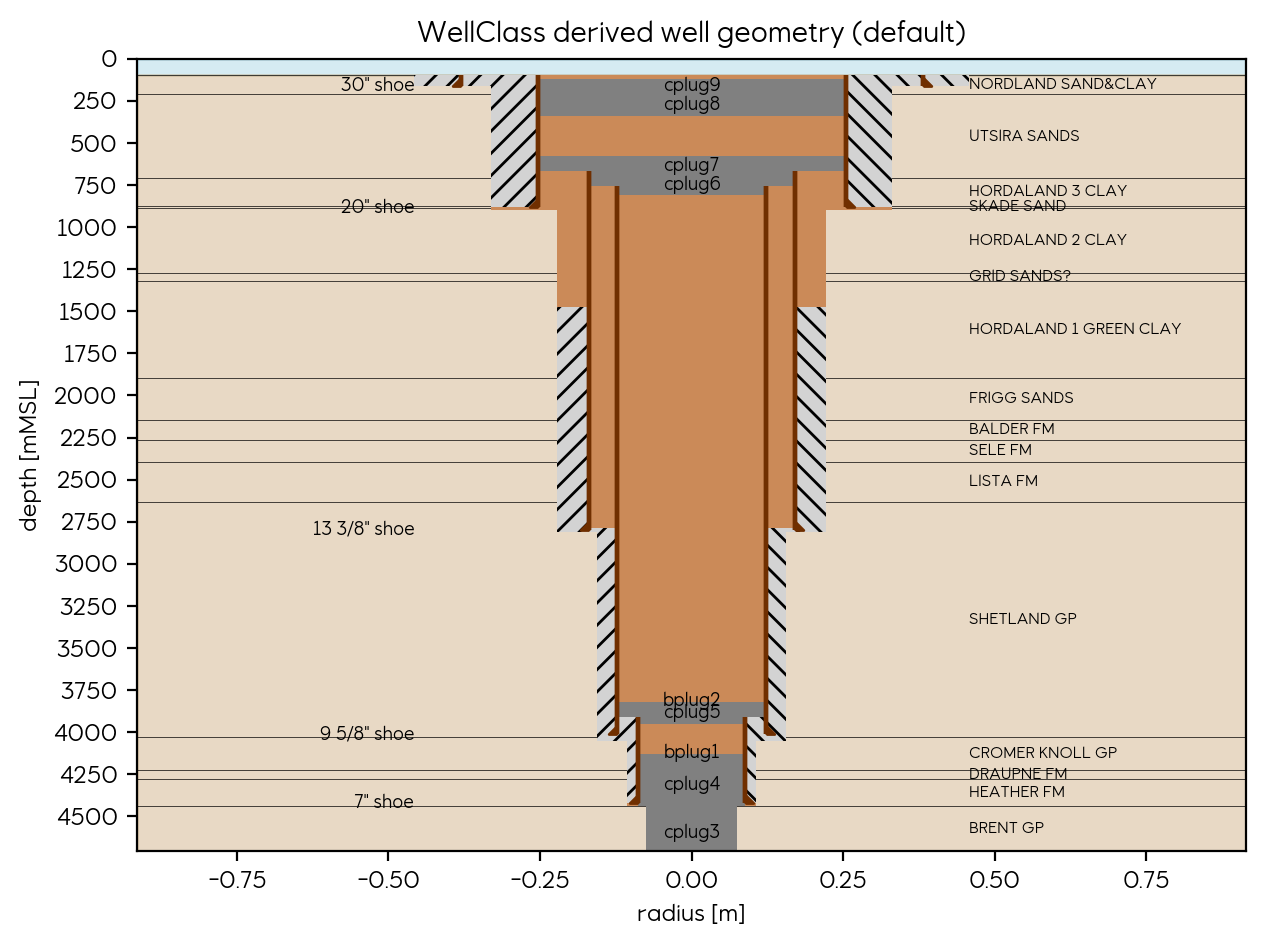

In [8]:
import matplotlib.pyplot as plt
from src.WellClass.libs.plotting.plot_sketch import plot_sketch

# plot_sketch(processed_well, ...) and processed_well.plot_sketch(...) are equivalent
fig, ax = plot_sketch(processed_well, draw_open_hole=False)
ax.set_title('WellClass derived well geometry (default)')
fig.tight_layout()
plt.show()

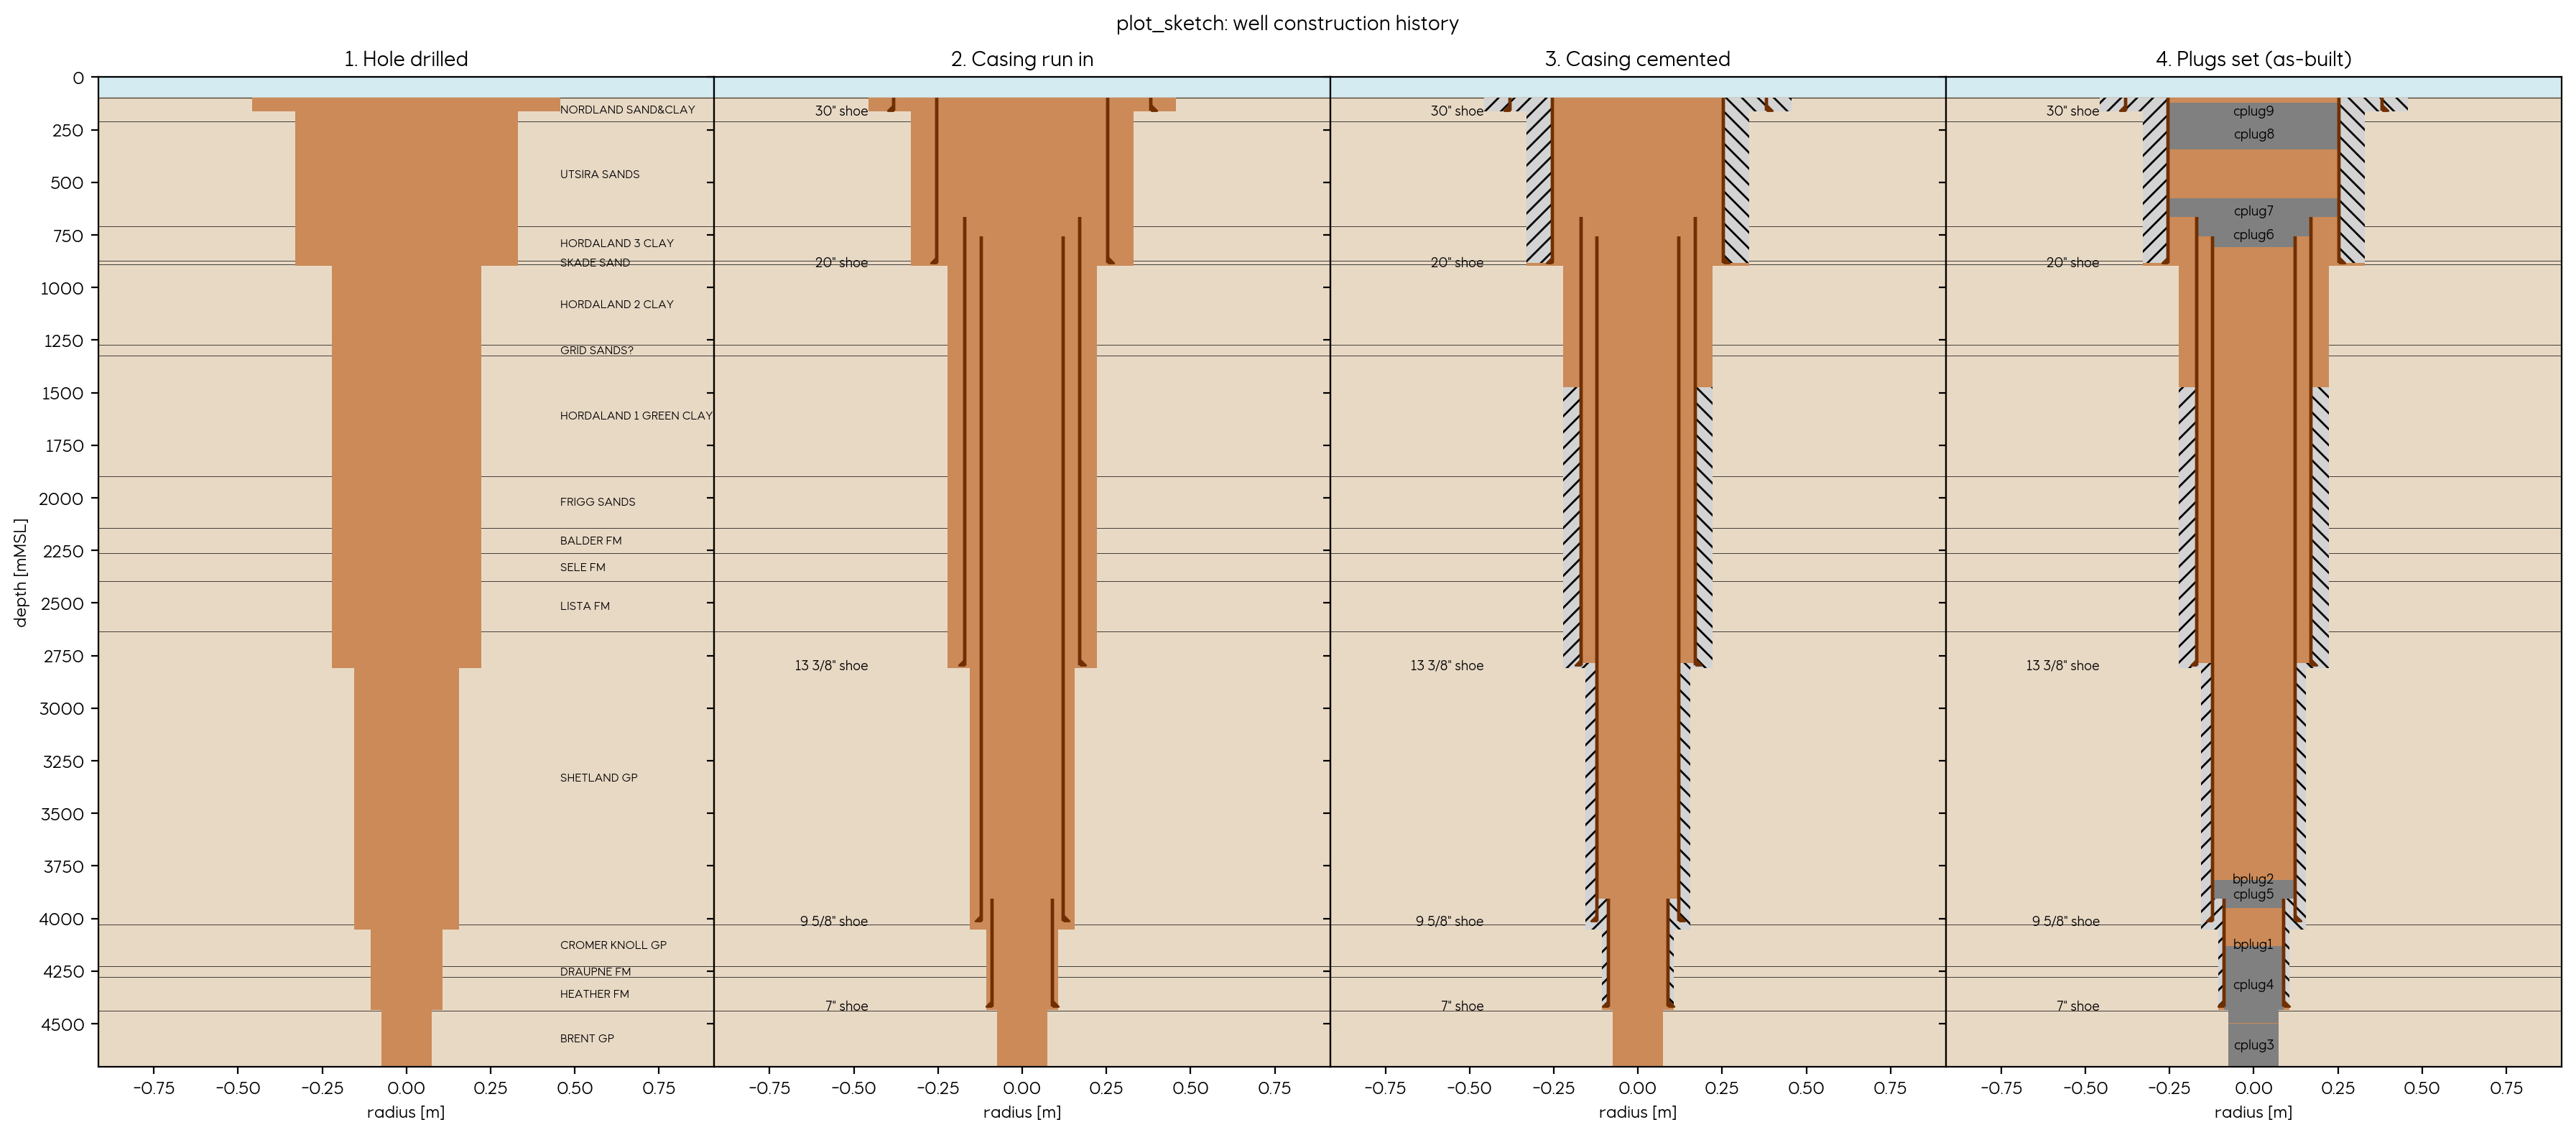

In [9]:
# plot_sketch accepts draw_* toggles, so a construction-history sequence can be
# built by progressively enabling elements in the order they occur physically:
# drill hole -> run casing -> cement it -> set plugs. Geology bands are always shown,
# but their text labels are only needed once (panel 1) to demonstrate the toggle.
fig, axes = plt.subplots(1, 4, figsize=(18, 8), sharey=True)

common = dict(draw_geology=True)

processed_well.plot_sketch(ax=axes[0], draw_open_hole=False, draw_casings=False, draw_casing_shoes=False, draw_welded=False, draw_cement_bond=False, draw_barriers=False, draw_annotation=False, draw_geology_annotation=True, **common)
axes[0].set_title('1. Hole drilled')

processed_well.plot_sketch(ax=axes[1], draw_open_hole=False, draw_casings=True, draw_cement_bond=False, draw_barriers=False, draw_plug_annotation=False, draw_geology_annotation=False, **common)
axes[1].set_title('2. Casing run in')

processed_well.plot_sketch(ax=axes[2], draw_open_hole=False, draw_casings=True, draw_cement_bond=True, draw_barriers=False, draw_plug_annotation=False, draw_geology_annotation=False, **common)
axes[2].set_title('3. Casing cemented')

processed_well.plot_sketch(ax=axes[3], draw_open_hole=False, draw_casings=True, draw_cement_bond=True, draw_barriers=True, draw_geology_annotation=False, **common)
axes[3].set_title('4. Plugs set (as-built)')

# with wspace=0, panels butt together, so only the leftmost keeps the shared y axis
for panel_ax in axes[1:]:
    panel_ax.set_ylabel('')
    panel_ax.tick_params(labelleft=False)

fig.suptitle('plot_sketch: well construction history')
fig.tight_layout()
fig.subplots_adjust(wspace=0)
plt.show()

## One-page pressure and P-T quality control

default: p_datum=253.5 bar @ z_datum=2500.0 mMSL; p_delta=+0.0 bar; p_MSAD=145.0 bar @ z_MSAD=889.8 mMSL


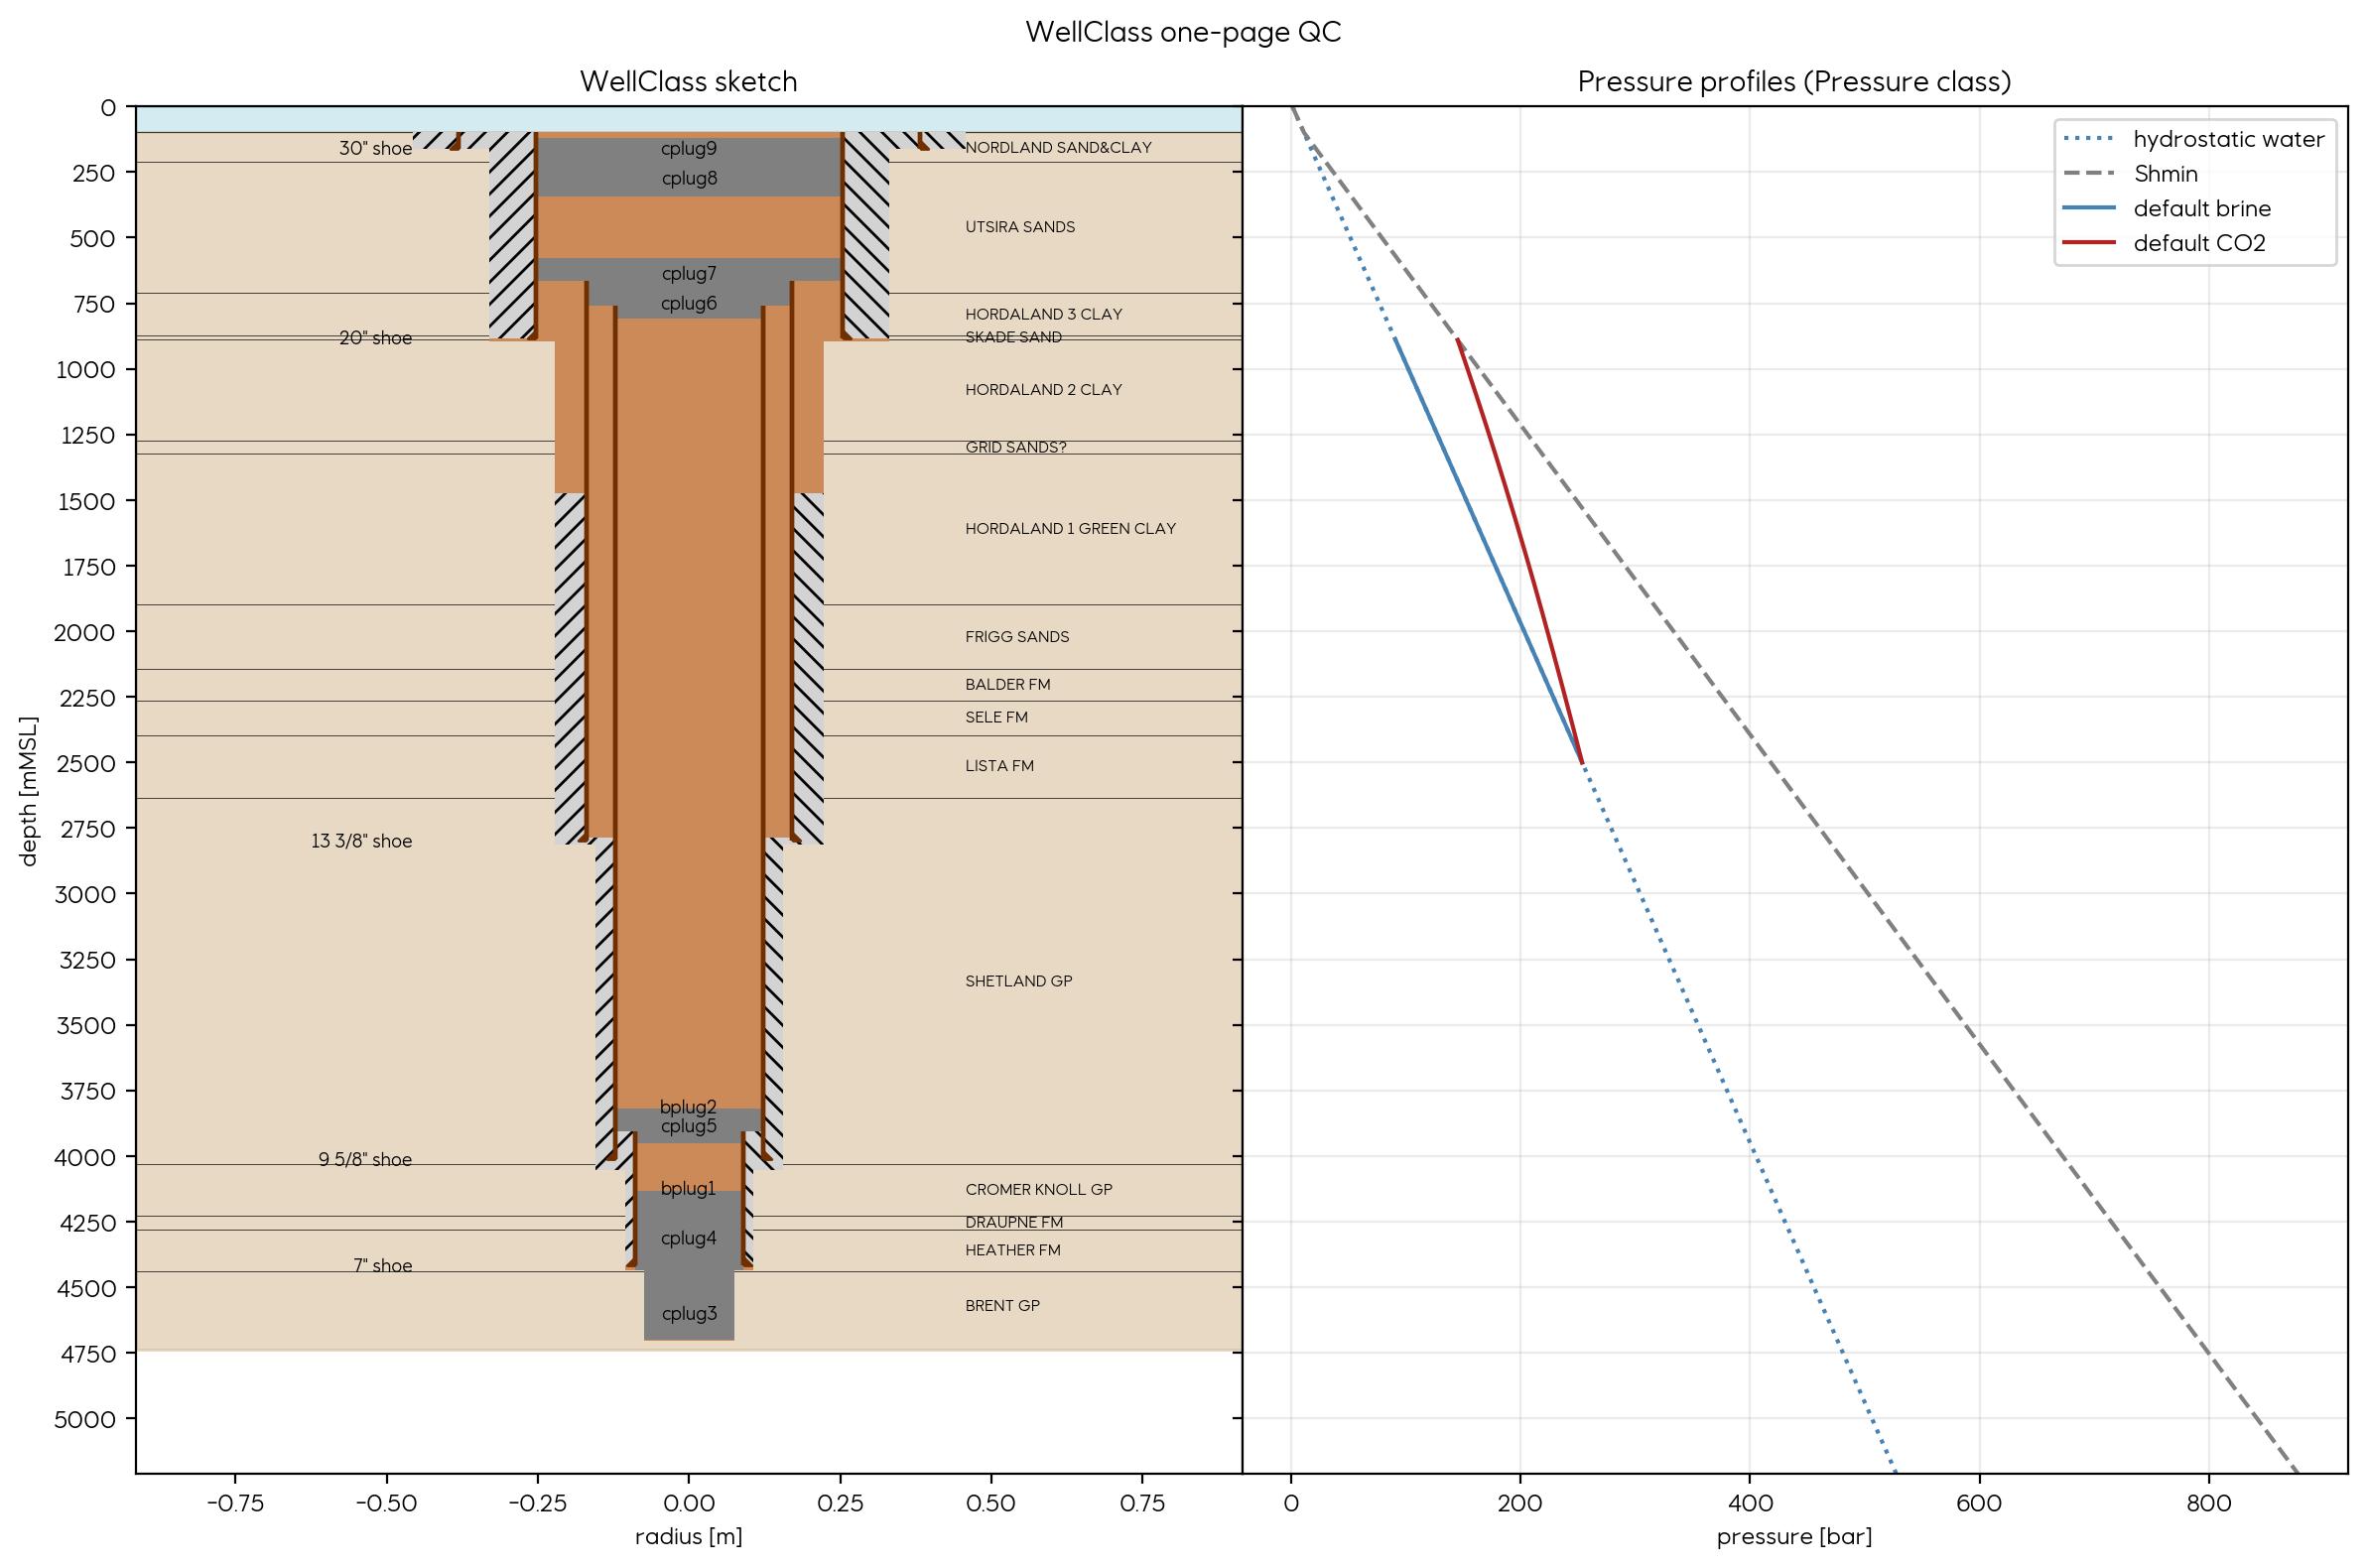

In [ ]:
from src.WellClass.libs.well_pressure import Pressure

pvt_path = root / 'test_data/pvt_constants'

# Frigg has no subsurface_assumptions/temperature-gradient fields, so these are illustrative.
# Pressure only needs the well header, a co2_datum, and the PVT path - it wires the
# PressureTable/PressureScenario machinery internally.
pressure = Pressure(
    header=processed_well.header,
    co2_datum=2500.0,
    pvt_path=str(pvt_path),
    ground_temperature=4.0,
    geothermal_gradient=40.0,
)

table = pressure.table
scenario = pressure.scenarios['default']
display = scenario.display_curves()

fig, (ax_well, ax_pressure) = plt.subplots(1, 2, figsize=(12, 8), sharey=True)
plot_sketch(processed_well, ax=ax_well)
ax_well.set_title('WellClass sketch')

ax_pressure.plot(table.hydrostatic_pressure, table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
ax_pressure.plot(table.min_horizontal_stress, table.depth, color='gray', linestyle='--', label='Shmin')
ax_pressure.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='default brine')
ax_pressure.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='default CO2')
print(
    f'default: p_datum={scenario.p_fluid_datum:.1f} bar @ z_datum={scenario.z_fluid_datum:.1f} mMSL; '
    f'p_delta={scenario.p_delta:+.1f} bar; p_MSAD={scenario.p_MSAD:.1f} bar @ z_MSAD={scenario.z_MSAD:.1f} mMSL'
)

ax_pressure.set_title('Pressure profiles (Pressure class)')
ax_pressure.set_xlabel('pressure [bar]')
ax_pressure.set_ylim(0, float(table.depth.max()))
ax_pressure.invert_yaxis()
ax_pressure.grid(alpha=0.25)
ax_pressure.legend()

# with wspace=0, panels butt together, so only the leftmost keeps the shared y axis
ax_pressure.set_ylabel('')
ax_pressure.tick_params(labelleft=False)

fig.suptitle('WellClass one-page QC')
fig.tight_layout()
fig.subplots_adjust(wspace=0)
plt.show()

### Explicit Datum Pressure Scenario

Providing `z_fluid_datum` and `p_fluid_datum` derives `p_delta` from their
difference from hydrostatic pressure at the datum, and shifts the brine profile
by that amount.

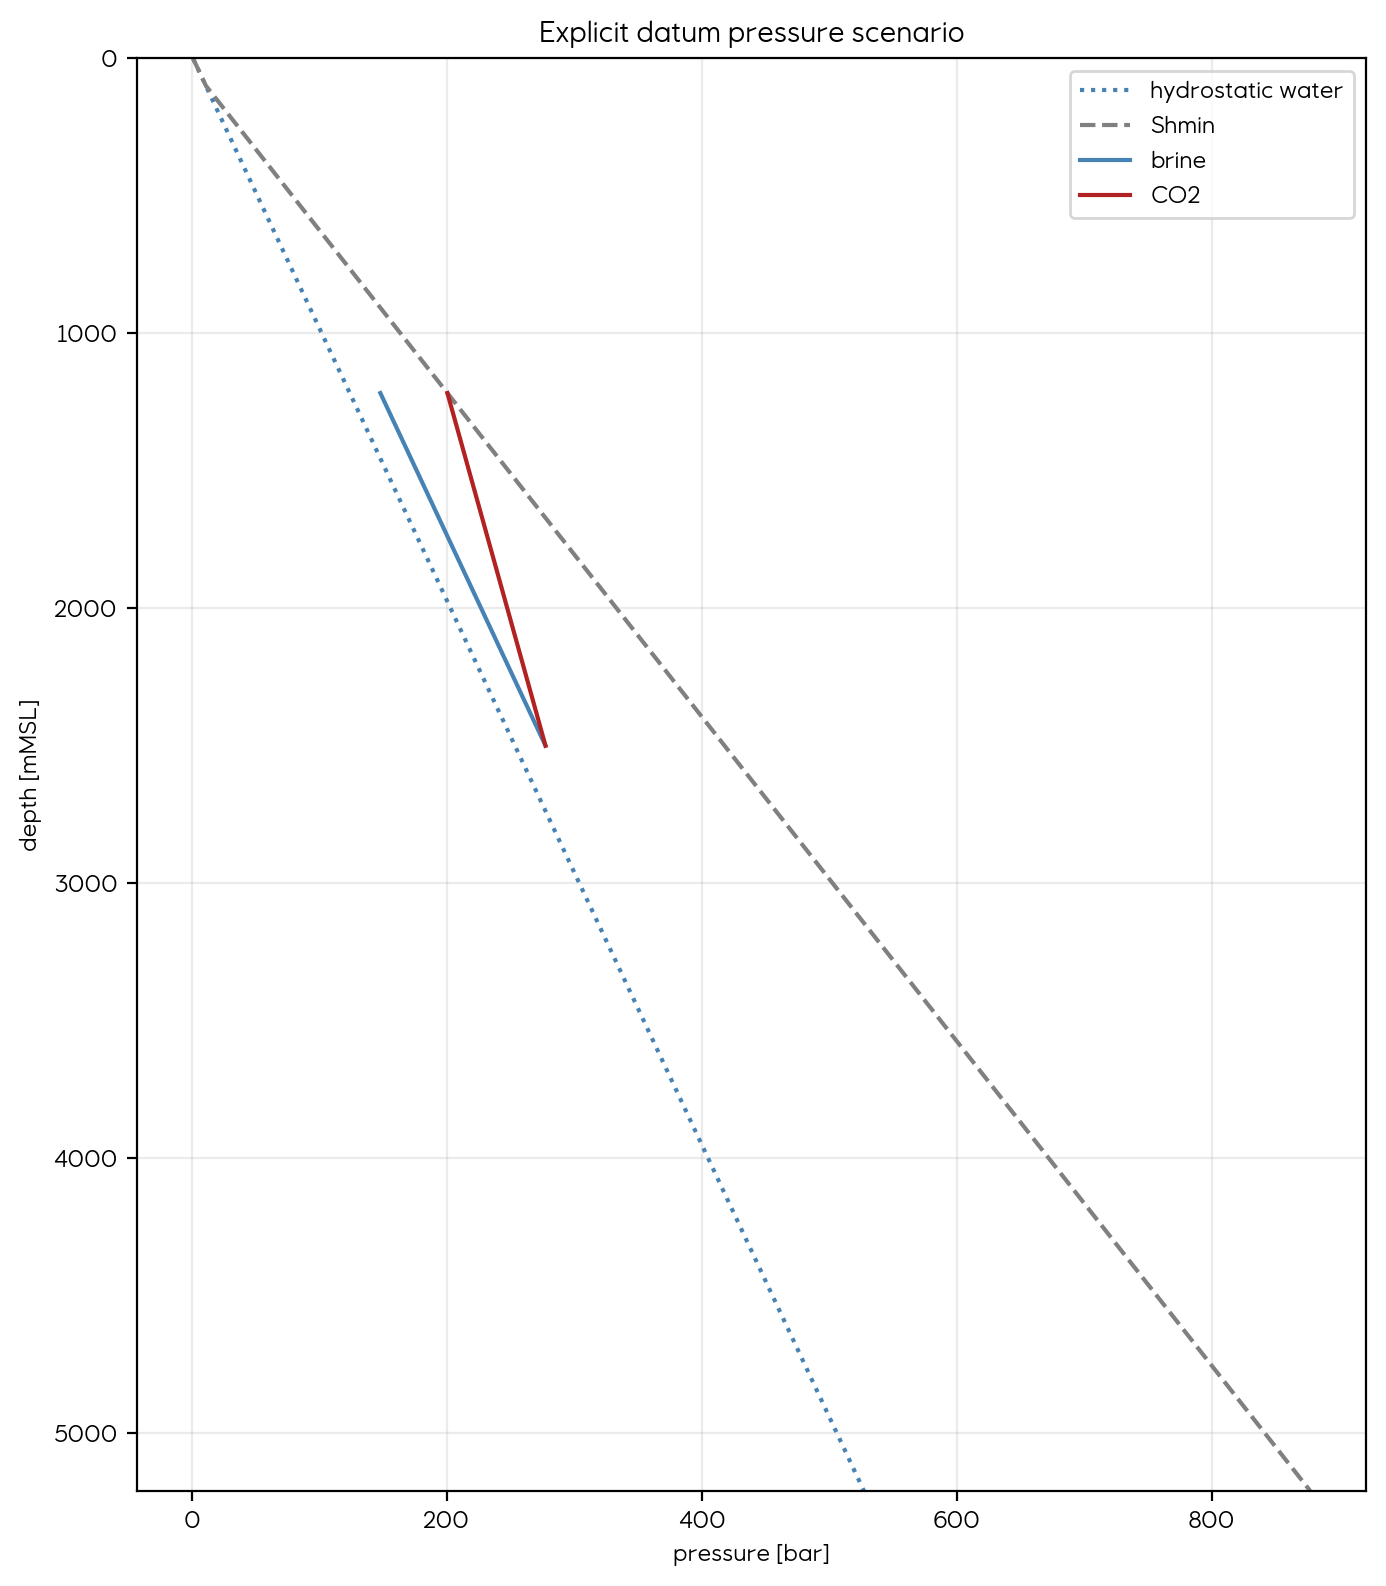

p_datum=277.5 bar @ z_datum=2500.0 mMSL; p_delta=+24.0 bar


In [ ]:
hydrostatic_at_datum = float(np.interp(2500.0, table.depth, table.hydrostatic_pressure))
datum_overpressure = pressure.add_scenario(
    'datum_overpressure',
    z_fluid_datum=2500.0,
    p_fluid_datum=hydrostatic_at_datum + 24.0,
    fluid_gradient=0.06,
)
display = datum_overpressure.display_curves()

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(table.hydrostatic_pressure, table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
ax.plot(table.min_horizontal_stress, table.depth, color='gray', linestyle='--', label='Shmin')
ax.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='brine')
ax.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='CO2')
ax.set_title('Explicit datum pressure scenario')
ax.set_xlabel('pressure [bar]')
ax.set_ylabel('depth [mMSL]')
ax.set_ylim(0, float(table.depth.max()))
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f'p_datum={datum_overpressure.p_fluid_datum:.1f} bar @ z_datum={datum_overpressure.z_fluid_datum:.1f} mMSL; '
    f'p_delta={datum_overpressure.p_delta:+.1f} bar'
)

### Store-Anchored Scenario

Providing a shallower `z_store`/`p_store` pair anchors fluid integration there.
The curve then supplies `p_fluid_datum` at the retained `z_fluid_datum`, which
in turn derives `p_delta` and the brine profile.

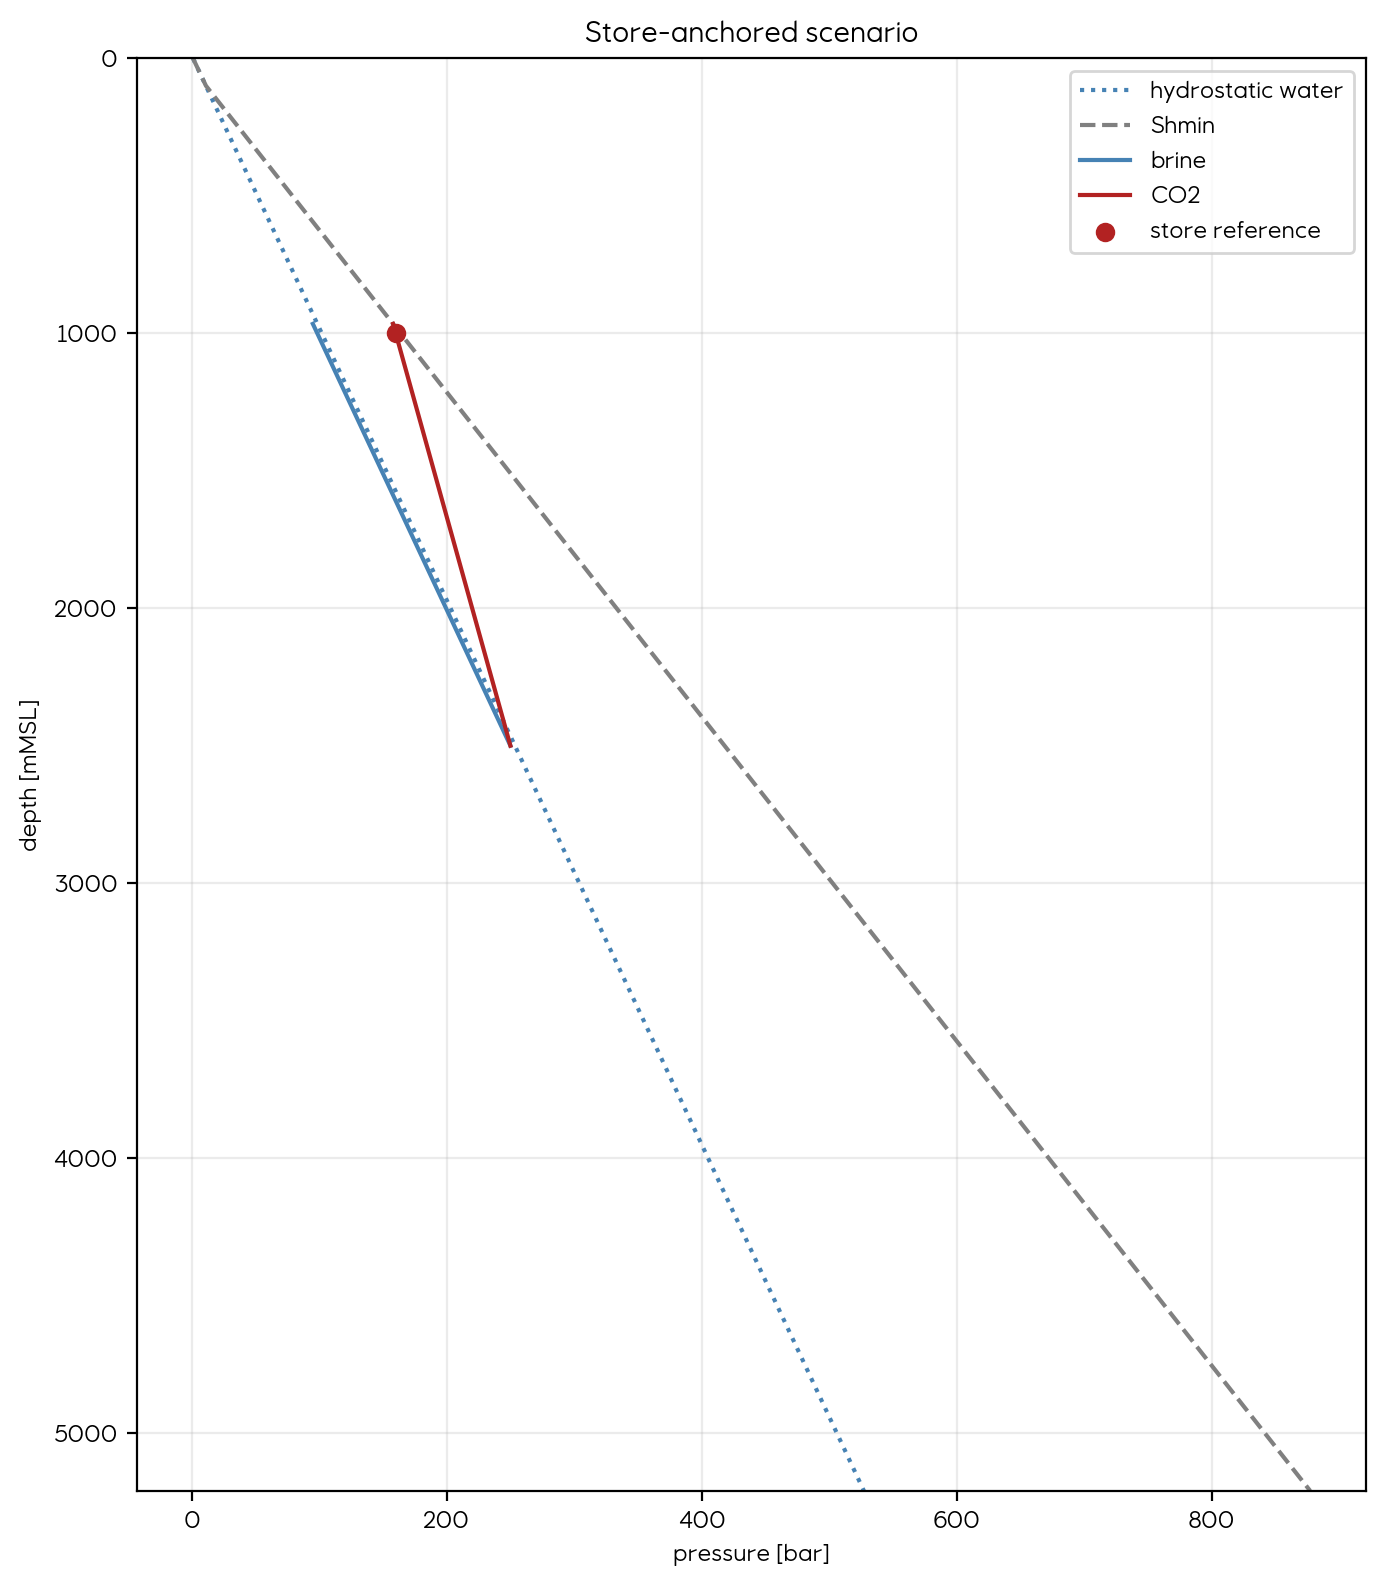

p_store=160.0 bar @ z_store=1000.0 mMSL; p_datum=250.0 bar @ z_datum=2500.0 mMSL; p_delta=-3.5 bar


In [ ]:
store_reference = pressure.add_scenario(
    'store_reference',
    z_fluid_datum=2500.0,
    z_store=1000.0,
    p_store=160.0,
    fluid_gradient=0.06,
)
display = store_reference.display_curves()

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(table.hydrostatic_pressure, table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
ax.plot(table.min_horizontal_stress, table.depth, color='gray', linestyle='--', label='Shmin')
ax.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='brine')
ax.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='CO2')
ax.scatter(store_reference.p_store, store_reference.z_store, color='firebrick', zorder=5, label='store reference')
ax.set_title('Store-anchored scenario')
ax.set_xlabel('pressure [bar]')
ax.set_ylabel('depth [mMSL]')
ax.set_ylim(0, float(table.depth.max()))
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f'p_store={store_reference.p_store:.1f} bar @ z_store={store_reference.z_store:.1f} mMSL; '
    f'p_datum={store_reference.p_fluid_datum:.1f} bar @ z_datum={store_reference.z_fluid_datum:.1f} mMSL; '
    f'p_delta={store_reference.p_delta:+.1f} bar'
)

### MSAD-Anchored Scenario

Providing `z_MSAD` uses Shmin at that depth as the fluid-pressure integration
anchor. `z_store` then acts as a depth query: `p_store` is read from the
resulting fluid curve. Without an explicit datum, `z_store` also becomes the
fluid datum. Here the base of the selected plug provides the MSAD depth.

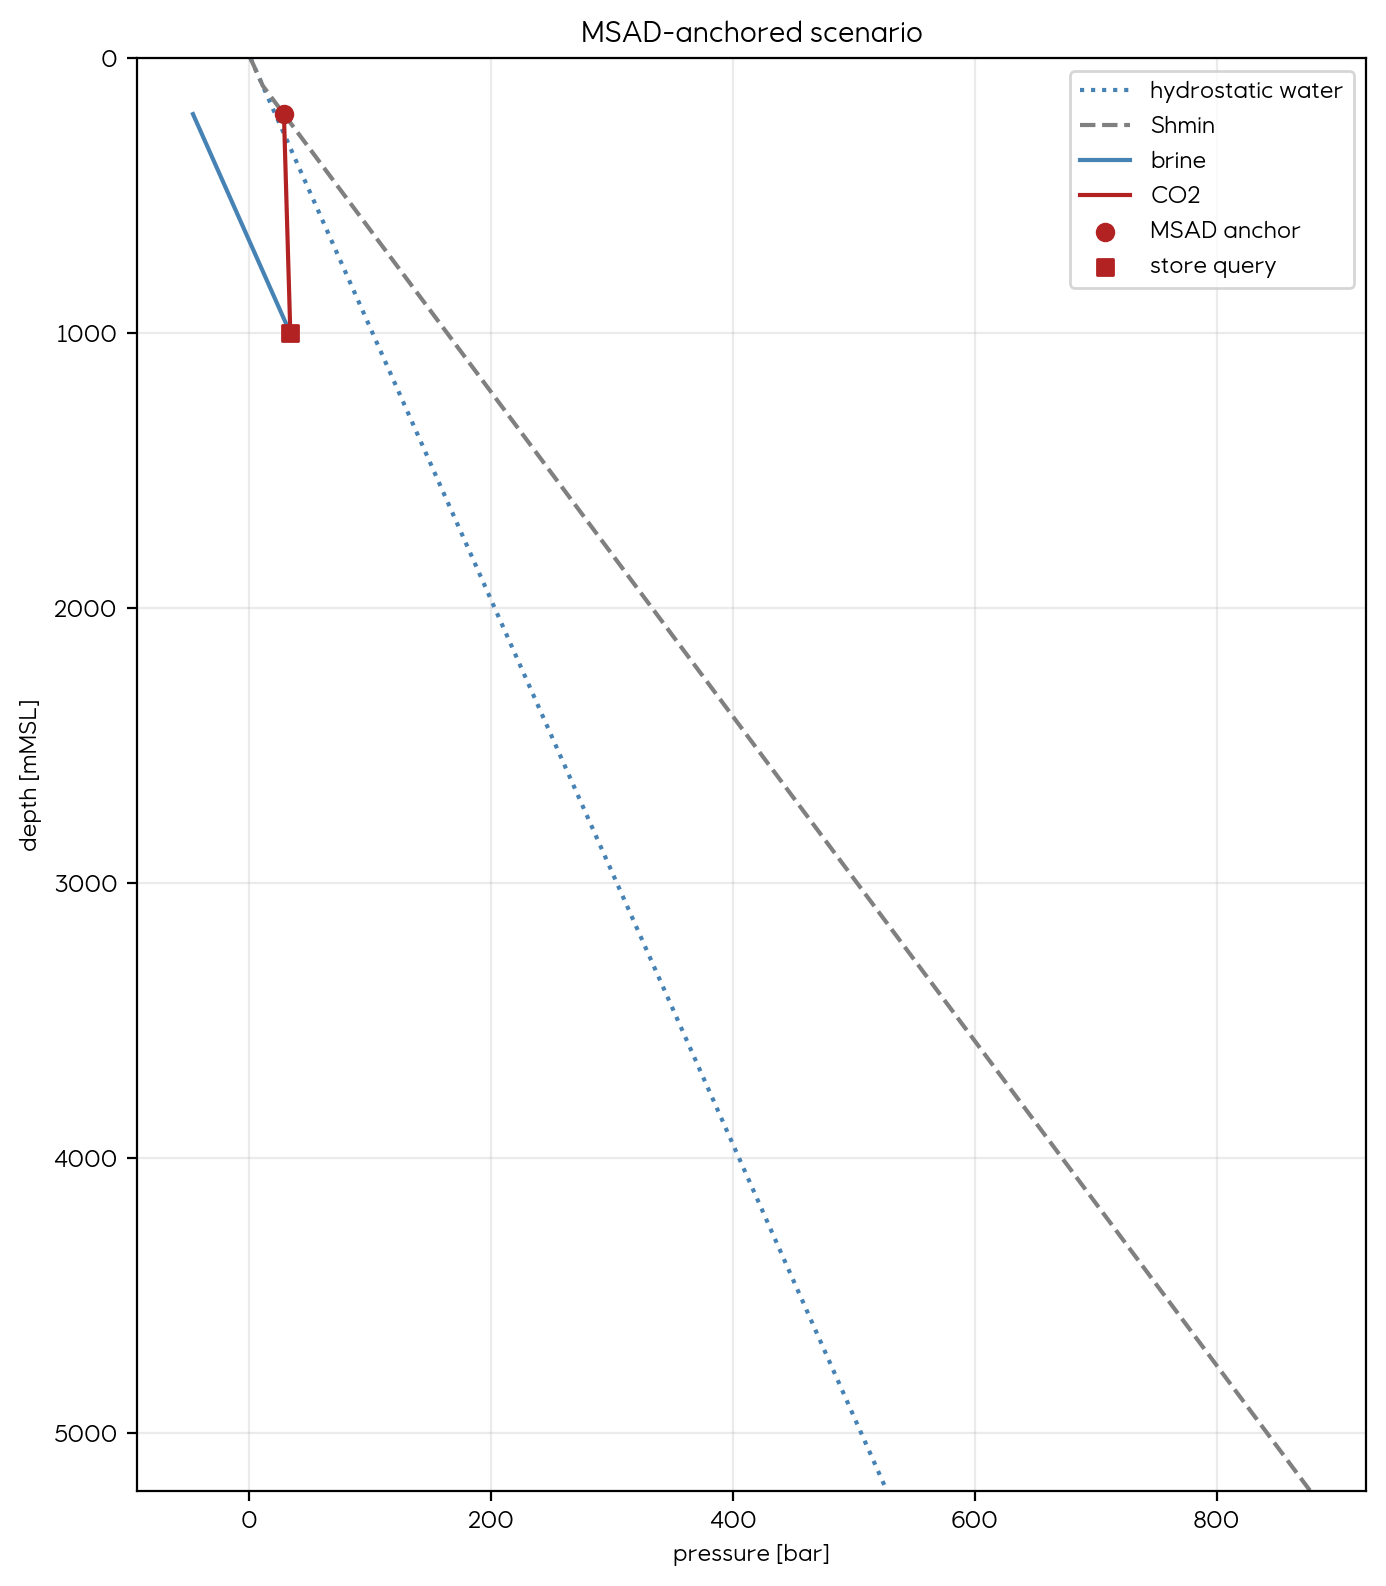

p_MSAD=28.6 bar @ z_MSAD=203.0 mMSL; p_store=34.0 bar @ z_store=1000.0 mMSL; p_datum=34.0 bar @ z_datum=1000.0 mMSL; p_delta=-68.1 bar


In [ ]:
msad_anchor = pressure.add_scenario(
    'plug_msad',
    z_MSAD=plug_properties['bottom_tvd_msl'],
    z_store=1000.0,
)
display = msad_anchor.display_curves()

fig, ax = plt.subplots(figsize=(7, 8))
ax.plot(table.hydrostatic_pressure, table.depth, color='steelblue', linestyle=':', label='hydrostatic water')
ax.plot(table.min_horizontal_stress, table.depth, color='gray', linestyle='--', label='Shmin')
ax.plot(display['brine_pressure'], display['brine_depth'], color='steelblue', label='brine')
ax.plot(display['fluid_pressure'], display['fluid_depth'], color='firebrick', label='CO2')
ax.scatter(msad_anchor.p_MSAD, msad_anchor.z_MSAD, color='firebrick', zorder=5, label='MSAD anchor')
ax.scatter(msad_anchor.p_store, msad_anchor.z_store, color='firebrick', marker='s', zorder=5, label='store query')
ax.set_title('MSAD-anchored scenario')
ax.set_xlabel('pressure [bar]')
ax.set_ylabel('depth [mMSL]')
ax.set_ylim(0, float(table.depth.max()))
ax.invert_yaxis()
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

print(
    f'p_MSAD={msad_anchor.p_MSAD:.1f} bar @ z_MSAD={msad_anchor.z_MSAD:.1f} mMSL; '
    f'p_store={msad_anchor.p_store:.1f} bar @ z_store={msad_anchor.z_store:.1f} mMSL; '
    f'p_datum={msad_anchor.p_fluid_datum:.1f} bar @ z_datum={msad_anchor.z_fluid_datum:.1f} mMSL; '
    f'p_delta={msad_anchor.p_delta:+.1f} bar'
)

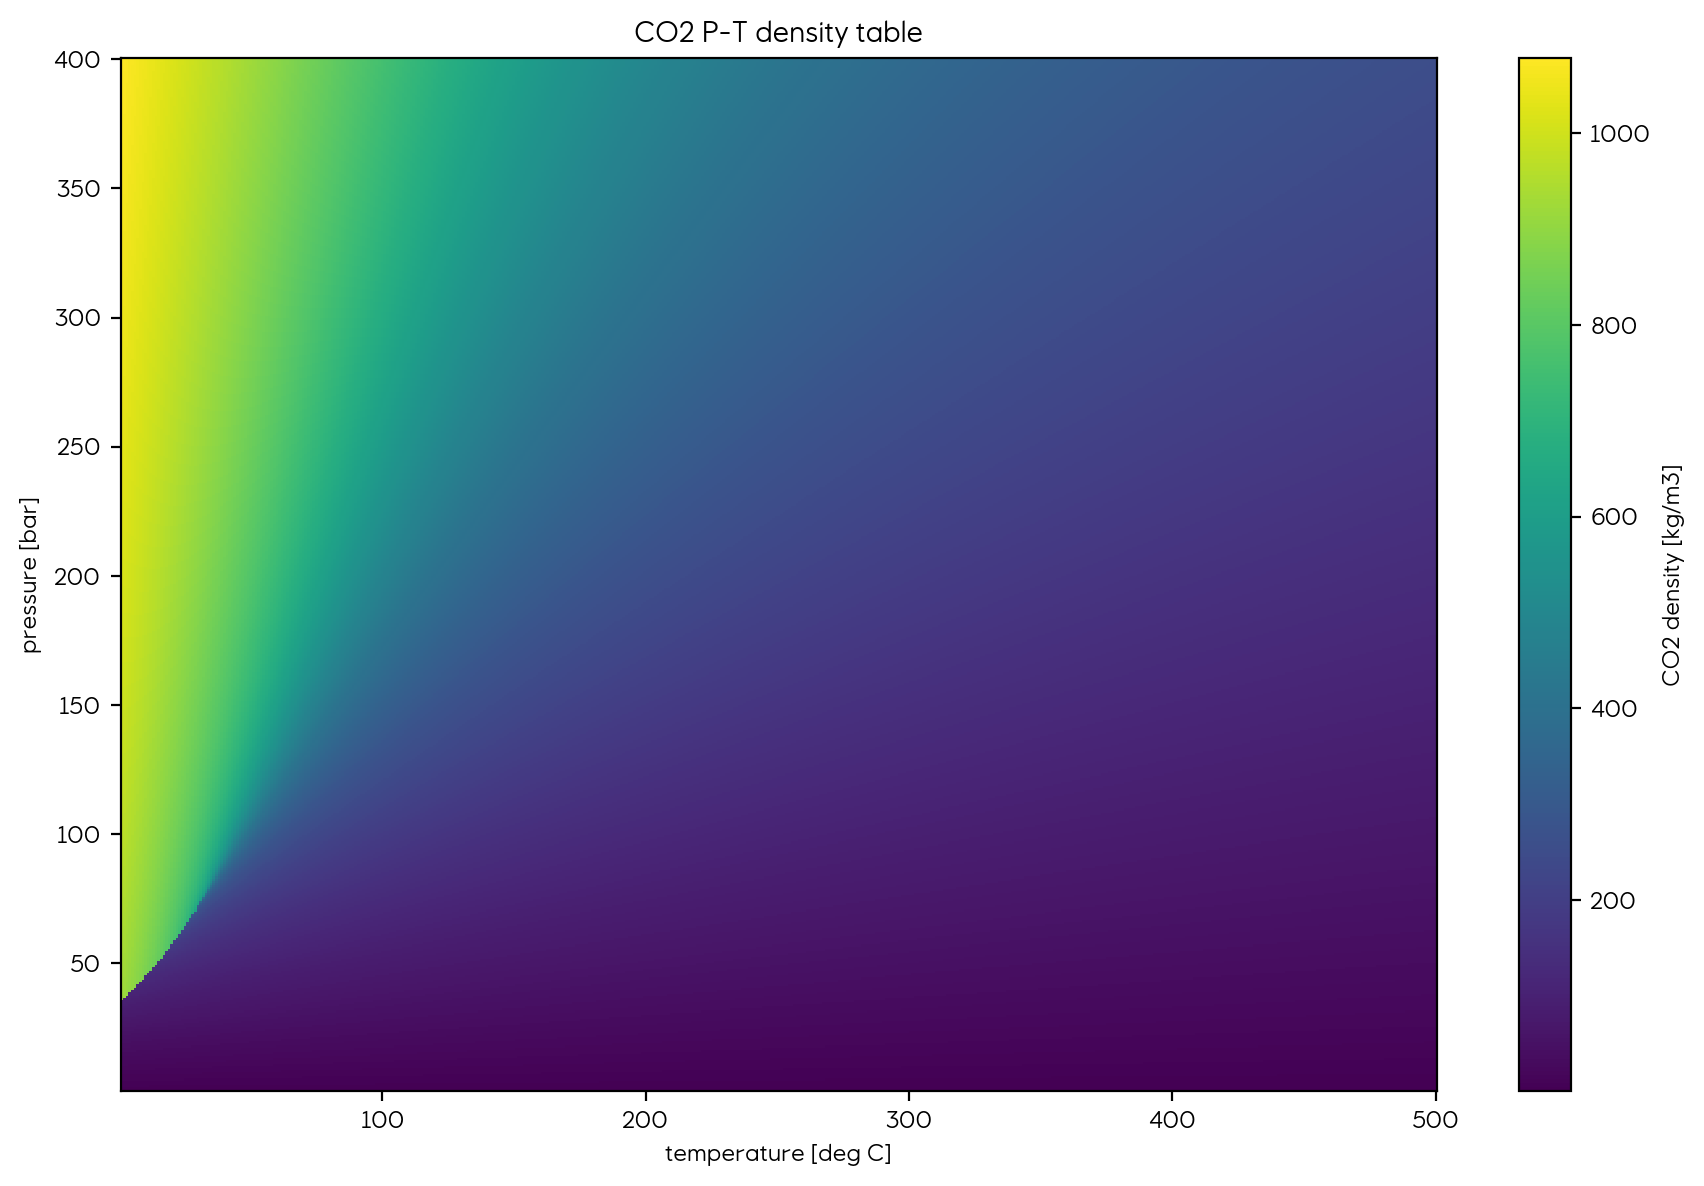

In [14]:
from src.WellClass.libs.pvt.pvt import get_pvt

temperatures, pressures, rho_co2, rho_brine = get_pvt(str(pvt_path))

fig, ax = plt.subplots(figsize=(9, 6))
image = ax.pcolormesh(temperatures, pressures, rho_co2, shading='auto', cmap='viridis')
ax.set_title('CO2 P-T density table')
ax.set_xlabel('temperature [deg C]')
ax.set_ylabel('pressure [bar]')
fig.colorbar(image, ax=ax, label='CO2 density [kg/m3]')
fig.tight_layout()
plt.show()

In [15]:
assert len(processed_well.borehole) > 0
assert len(processed_well.annulus) > 0
assert all(row['bottom_rkb'] >= row['top_rkb'] for row in processed_well.borehole)
print('WellClass derivation checks passed')

WellClass derivation checks passed
